# Exploratory Data Analysis (EDA)
Analyzing the feature-engineered market data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
BASE_DIR = Path().resolve().parent
DATA_FILE = BASE_DIR / 'data' / 'processed' / 'market_data_features.csv'

df = pd.read_csv(DATA_FILE)
df['Date'] = pd.to_datetime(df['Date'])
print(f'Data shape: {df.shape}')
df.head()

Data shape: (12692, 16)


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Return_30D,MA20,MA50,Volatility_30D,Annualized_Volatility,Avg_Volume_20D,Volume_Change
0,2024-01-02,AAPL,187.149994,188.440002,183.889999,185.639999,183.403992,82488700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-03,AAPL,184.220001,185.880005,183.429993,184.250000,182.030746,58414500,-0.007488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-04,AAPL,182.149994,183.089996,180.880005,181.910004,179.718933,71983600,-0.012700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-05,AAPL,181.990005,182.759995,180.169998,181.179993,178.997696,62379700,-0.004013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-08,AAPL,182.089996,185.600006,181.500000,185.559998,183.324951,59144500,0.024175,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Closing Prices of Top Tech Stocks

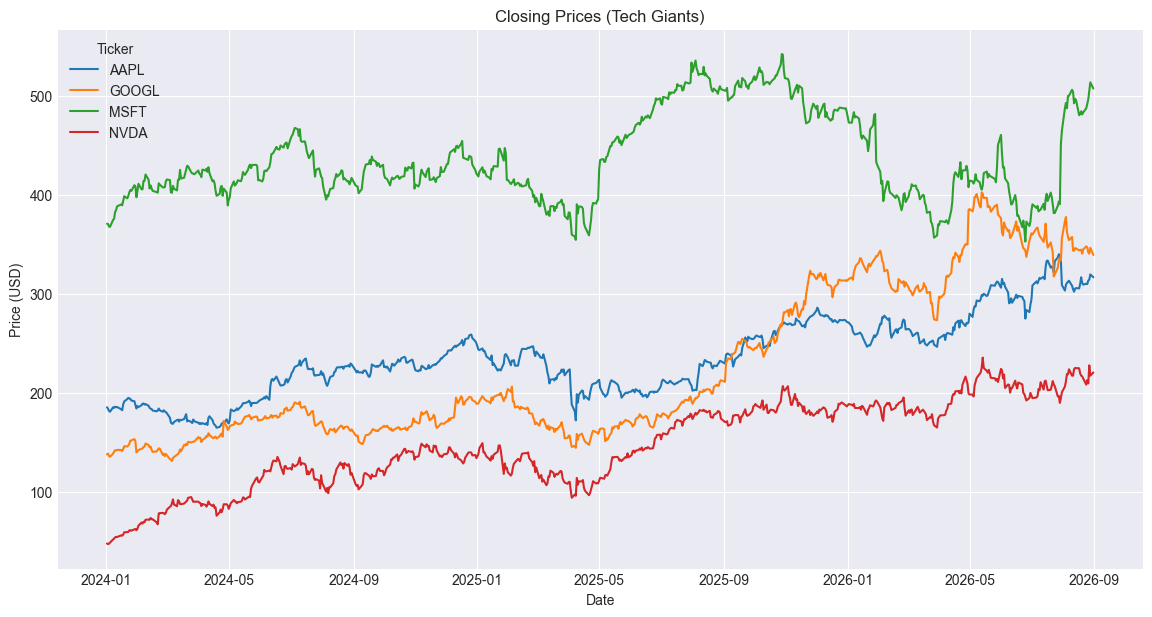

In [3]:
tech_tickers = ['AAPL', 'MSFT', 'NVDA', 'GOOGL']
tech_df = df[df['Ticker'].isin(tech_tickers)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=tech_df, x='Date', y='Close', hue='Ticker')
plt.title('Closing Prices (Tech Giants)')
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.show()

## 2. Annualized Volatility over Time

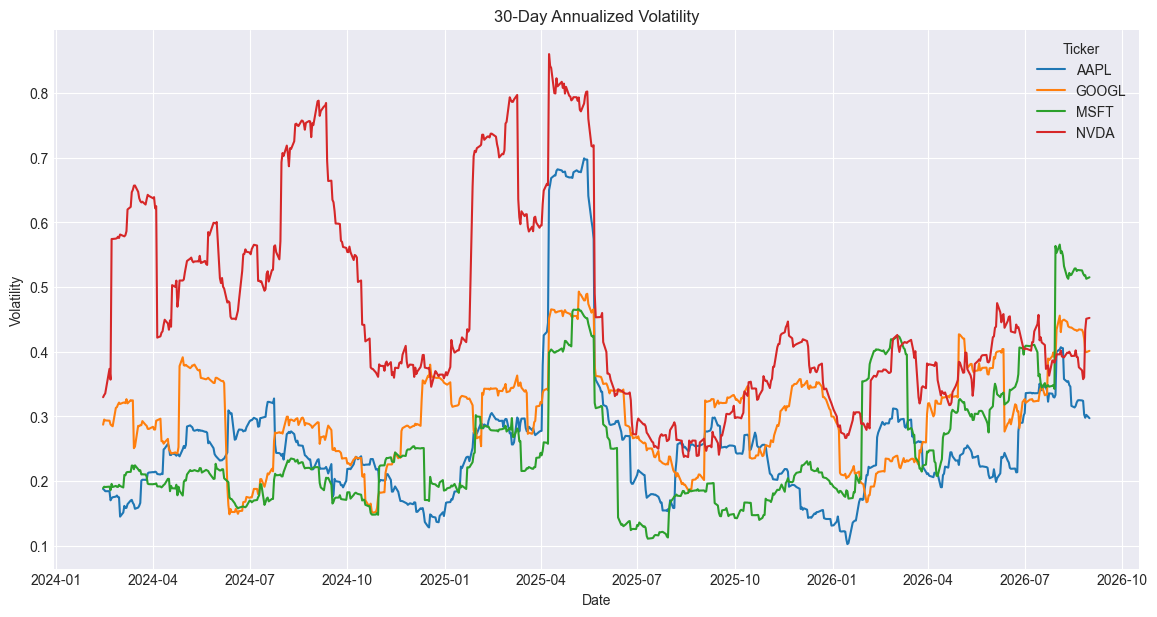

In [4]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=tech_df, x='Date', y='Annualized_Volatility', hue='Ticker')
plt.title('30-Day Annualized Volatility')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.show()

## 3. Return Correlations

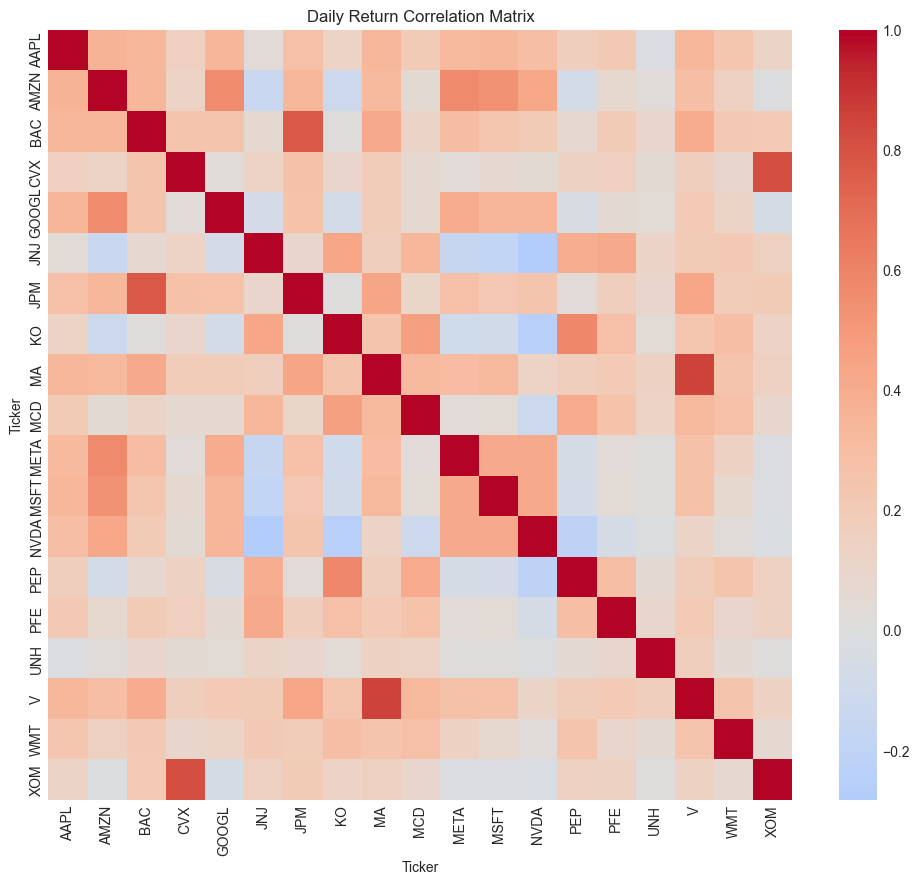

In [5]:
pivot_returns = df.pivot(index='Date', columns='Ticker', values='Daily_Return')
corr_matrix = pivot_returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Daily Return Correlation Matrix')
plt.show()